# Colab 6
## Node2Vec
initially, we import the library and we create a small wrapper class which will expose only a few hyperparameters that we need in order to tune our solution. 

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import networkx as nx 

from tqdm import tqdm 
#from nodevectors import Node2Vec
from numpy.linalg import norm

class Node2VecNew(Node2Vec):
    """Parameters 
    p -> p parameter of node2vec
    q -> q parameter of node2vec
    d -> dimensinality of the embedding vectors
    """ 

    def __init__(self, p = 1, q = 1, d = 32):
        super().__init__(
            n_components = d,
            walklen = 10,
            epochs = 50,
            return_weight = 1.0/p,
            nieghbor_weight = 1.0/q,
            threads = 0,
            w2vparams={'window': 4,
                                'negative': 5,
                                'iter': 10,
                                'ns_exponent': 0.5,
                                'batch_words': 128})


NameError: name 'Node2Vec' is not defined

In [ ]:
# Load the Zachary's Karate Club as a NetworkX Graph object
KCG = nx.karate_club_graph()
n2v = Node2VecNew(1, 2, 2)
n2v.fit(KCG)

In [ ]:
embeddings = []
for node in KCG.nodes:
  embedding = list(n2v.predict(node))
  club = KCG.nodes[node]['club']
  embeddings.append(embedding + [club])

# Construct a pandas dataframe with the 2D embeddings from node2vec,
# plus the club name that each node belongs to after the split
df = pd.DataFrame(embeddings, columns=['x', 'y', 'club'])

### Barbell graphs
We will learn embeddings of the barbell graphs. 

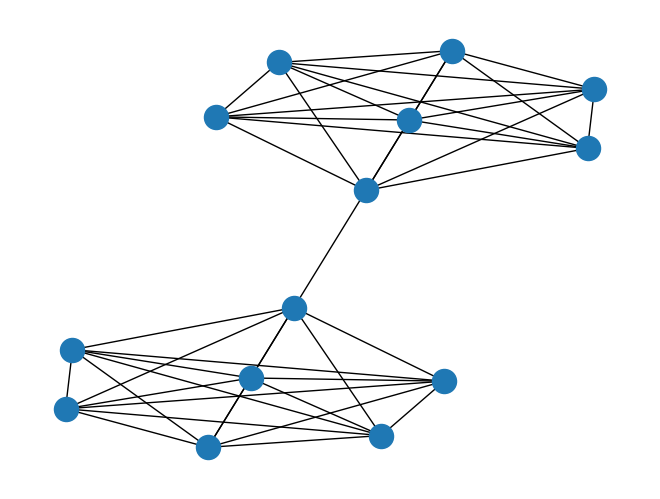

In [3]:
toy_barbell = nx.barbell_graph(7, 0)
nx.draw_kamada_kawai(toy_barbell)

In [ ]:
toy_barbell_large = nx.barbell_graph(1000, 0)
n2v = Node2VecNew(1, 1, 2)
n2v.fit(KCG)


We will create a function for calculating the cosine similarity between a node's embedding and all the other graph  nodes' embeddings.

In [ ]:
def cos_sim(n: int):
    similarities = []
    embed_of_n = n2v.predict(n)
    for node in toy_barbell_large.nodes:
        emd_of_node = n2v.predict(node)
        cs = np.dot(embed_of_n, emb_of_node) / norm(embed_of_n) * norm(emb_of_node)
        similarities.append(cs)